In [2]:
import numpy as np
import matplotlib.pyplot as plt
import casadi as cas

In [ ]:
def sorting_coordinates(x,y):
    angles = np.arctan2(y, x)
    sort_idx = np.argsort(angles)
    x_sorted = x[sort_idx]
    y_sorted = y[sort_idx]

    return x_sorted,y_sorted


N_points = 100

#  Main Circle in (x,y)
x_main_c = 0
y_main_c = 0

r_main   = 1
theta_main = np.linspace(0, 2*np.pi, N_points)

x_main = x_main_c +  r_main * np.cos(theta_main)
y_main = y_main_c +  r_main * np.sin(theta_main)

x_sorted_main,y_sorted_main = sorting_coordinates(x_main,y_main)


In [ ]:
size_problem = 100


opti = cas.Opti()

x_ref = opti.parameter(size_problem)
y = opti.parameter(size_problem)

alpha = opti.variable(size_problem)
beta  = opti.variable(size_problem) 

radius = cas.MX.ones(size_problem)


f_ext_x = np.zeros_like(size_problem)
f_ext_y = np.zeros_like(size_problem)

J_cost = cas.norm_2(alpha-f_ext_x)**2 + cas.norm_2(beta-f_ext_y)**2
opti.minimize(J_cost)

opti.subject_to(x**2*(alpha+1) + y**2*(beta+1) == radius**2)

opti.subject_to(alpha >= 0)
opti.subject_to(alpha <= 10)
opti.subject_to(beta >= 0)
opti.subject_to(beta <= 10)

theta = np.linspace(1,size_problem,size_problem)
y_init =  np.cos(theta)
x_init =  np.sin(theta)

opti.set_value(x, x_init)
opti.set_value(y, y_init)

opti.set_initial(alpha,np.ones(size_problem))
opti.set_initial(beta,np.ones(size_problem))

opti.solver('ipopt')
sol = opti.solve()



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      200
Number of nonzeros in inequality constraint Jacobian.:      400
Number of nonzeros in Lagrangian Hessian.............:    10100

Total number of variables............................:      200
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      100
Total number of inequality c

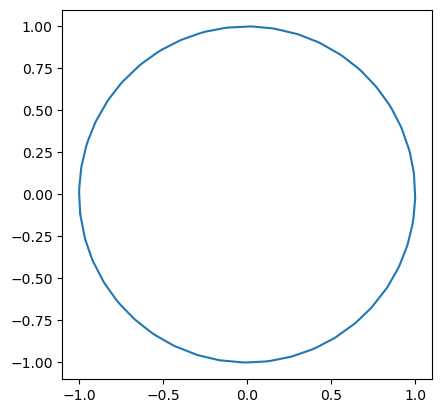

In [ ]:
x = sol.value(x)
y = sol.value(y)

alpha = sol.value(alpha)
beta  = sol.value(beta)

a=0
b=1
r=0.5
theta = np.linspace(0, 2*np.pi, 200)
x_new = a +  r * np.cos(theta)
y_new = b +  r * np.sin(theta)

x = x-x_new
y = y-y_new

angles = np.arctan2(y,x)

sort_idx = np.argsort(angles)
x_sorted = x[sort_idx]
y_sorted = y[sort_idx]


plt.plot(np.append(x_sorted, x_sorted[0]), np.append(y_sorted, y_sorted[0]), '-')
plt.gca().set_aspect('equal')
plt.show()

# plt.plot(x_val,y_val,'-o')
# plt.show()


